In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_auc_score, RocCurveDisplay)

In [7]:
#import the training and test data
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()


In [8]:
#Initialize logistic regression model
model = LogisticRegression(class_weight= 'balanced', max_iter= 2000)

In [9]:
#train the model
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [10]:
#make predictions
log_predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]

In [11]:
#Accuracy evaluation
accuracy_score(y_test, log_predictions)

0.7331440738112136

In [12]:
#Confusion matrix
print(confusion_matrix(y_test, log_predictions))

[[740 295]
 [ 81 293]]


In [13]:
#Classification report
print(classification_report(y_test, log_predictions))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.73      0.75      1409



In [14]:
#ROC AUC
roc_auc_score(y_test, probabilities)

0.8362293006794287

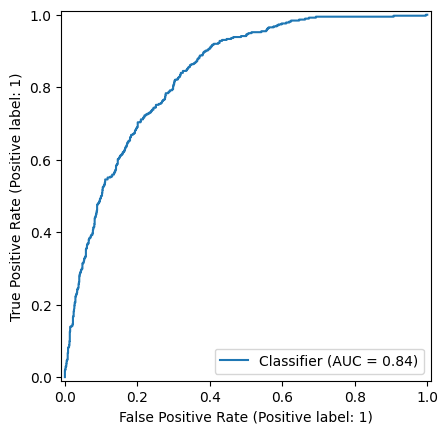

In [15]:
RocCurveDisplay.from_predictions(y_test, probabilities)

In [16]:
#compare with random forest and gradient boosting model
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

In [17]:
#train random forest
rf = RandomForestClassifier(class_weight= 'balanced', random_state= 42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
#train gradient boosting
gb = GradientBoostingClassifier(random_state= 42)
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [19]:
#predicitons of new models
rf_predictions = rf.predict(X_test)
gb_predictions = gb.predict(X_test)

In [20]:
#table that will compare the three models results
def model_comparison(name: str, y_true, model_predictions):
    return{'Name': name, 
           'Accuracy': accuracy_score(y_true, model_predictions),
           'Precision': precision_score(y_true, model_predictions),
           'Recall': recall_score(y_true, model_predictions),
           'F1 Score': f1_score(y_true, model_predictions)}

results = []
results.append(model_comparison('Logistic Regression', y_test, log_predictions))
results.append(model_comparison('Random Forest', y_test, rf_predictions))
results.append(model_comparison('Gradient Boosting', y_test, gb_predictions))

In [21]:
#put the result in a pandas dataframe
import pandas as pd
results_df  = pd.DataFrame(results)
results_df

,Name,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.733144,0.498299,0.783422,0.609148
1,Random Forest,0.785664,0.626761,0.475936,0.541033
2,Gradient Boosting,0.798439,0.655172,0.508021,0.572289


In [22]:
#Feature importance for Random Forest
important_feat = pd.Series(rf.feature_importances_, index= X_train.columns).sort_values(ascending= False)
important_feat.head(20)

TotalCharges                      0.194753
MonthlyCharges                    0.169339
Contract_Two year                 0.056955
InternetService_Fiber optic       0.046187
tenure_groups_0-1 year            0.039723
tenure_groups_3+ years            0.035941
PaymentMethod_Electronic check    0.035718
Contract_One year                 0.031289
gender_Male                       0.029345
TechSupport_Yes                   0.027896
PaperlessBilling_Yes              0.026679
OnlineSecurity_Yes                0.026255
Partner_Yes                       0.025479
OnlineBackup_Yes                  0.023048
Dependents_Yes                    0.020957
DeviceProtection_Yes              0.019875
SeniorCitizen                     0.019784
MultipleLines_Yes                 0.019468
StreamingMovies_Yes               0.019415
StreamingTV_Yes                   0.018019
dtype: float64

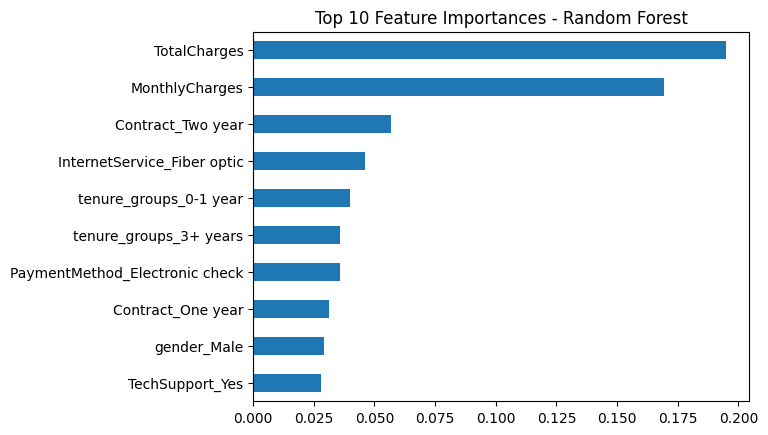

In [25]:
import matplotlib.pyplot as plt

important_feat.head(10).sort_values(ascending=True).plot(kind='barh')
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()


In [28]:
#check if removing the five weakest features improve random forest model
weak_features = important_feat.tail(5).index
X_train_reduced = X_train.drop(columns=weak_features)
X_test_reduced = X_test.drop(columns=weak_features)

rf.fit(X_train_reduced, y_train)
rf_new_preds = rf.predict(X_test_reduced)

print("New Accuracy:", accuracy_score(y_test, rf_new_preds))
print("New Precision:", precision_score(y_test, rf_new_preds))
print("New Recall:", recall_score(y_test, rf_new_preds))
print("New F1:", f1_score(y_test, rf_new_preds))

New Accuracy: 0.7849538679914834
New Precision: 0.6263345195729537
New Recall: 0.47058823529411764
New F1: 0.5374045801526718


## Moving Forward with Logistic Regression

We will use **logistic regression** as our primary model for the rest of this project. It offers the best balance of performance, interpretability, and efficiency for our churn prediction task. 

### A Note on Multicollinearity

We did not check for multicollinearity in our features. Since Random Forest and Gradient Boosting (which are robust to correlated features) did not outperform logistic regression, we can conclude that multicollinearity is not severe enough to harm our model's performance. The strong results from logistic regression confirm that any correlation among predictors is not negatively impacting our predictions.